# 04 — Pairs Trading

The most statistically rigorous strategy in this project. Instead of predicting price direction, we exploit the *relationship* between two assets.

**Core idea:** two stocks that share fundamental drivers (same sector, similar business model) tend to move together over time. When they drift apart, one of them is likely mispriced relative to the other — bet on convergence.

**What makes this work mathematically:** cointegration. Two non-stationary series $A$ and $B$ are cointegrated if there exists some $\beta$ such that:

$$\text{spread} = A_t - \beta B_t$$

is stationary (mean-reverting). We test for this using the Engle-Granger test. $\beta$ is estimated by OLS regression.

**Signal rule:** z-score of the spread relative to its rolling mean:
- z > +2 → spread is wide → short A, long B
- z < -2 → spread is narrow → long A, short B
- |z| < 0.5 → close position

This is market-neutral: simultaneous long and short positions hedge out broad market movements.

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data import load_multi
from backtester import run
from metrics import summary
from strategies.pairs_trading import test_cointegration, compute_spread, signals

## Step 1 — Test for cointegration

We pick Coca-Cola (KO) and Pepsi (PEP) as a classic pair — same industry, same consumer base, highly correlated fundamentals.

In [2]:
start = '2015-01-01'
end   = '2024-01-01'

prices = load_multi(['KO', 'PEP'], start, end)
KO  = prices['KO'].dropna()
PEP = prices['PEP'].dropna()

# align on common dates
KO, PEP = KO.align(PEP, join='inner')

is_coint, p_value = test_cointegration(KO, PEP)
print(f"Cointegration test (Engle-Granger)")
print(f"  p-value      : {p_value:.4f}")
print(f"  Cointegrated : {is_coint} (at 5% significance)")

Cointegration test (Engle-Granger)
  p-value      : 0.0095
  Cointegrated : True (at 5% significance)


## Step 2 — Compute the spread and z-score

Hedge ratio β : 0.2886
  For every 1 share of KO, short 0.289 shares of PEP


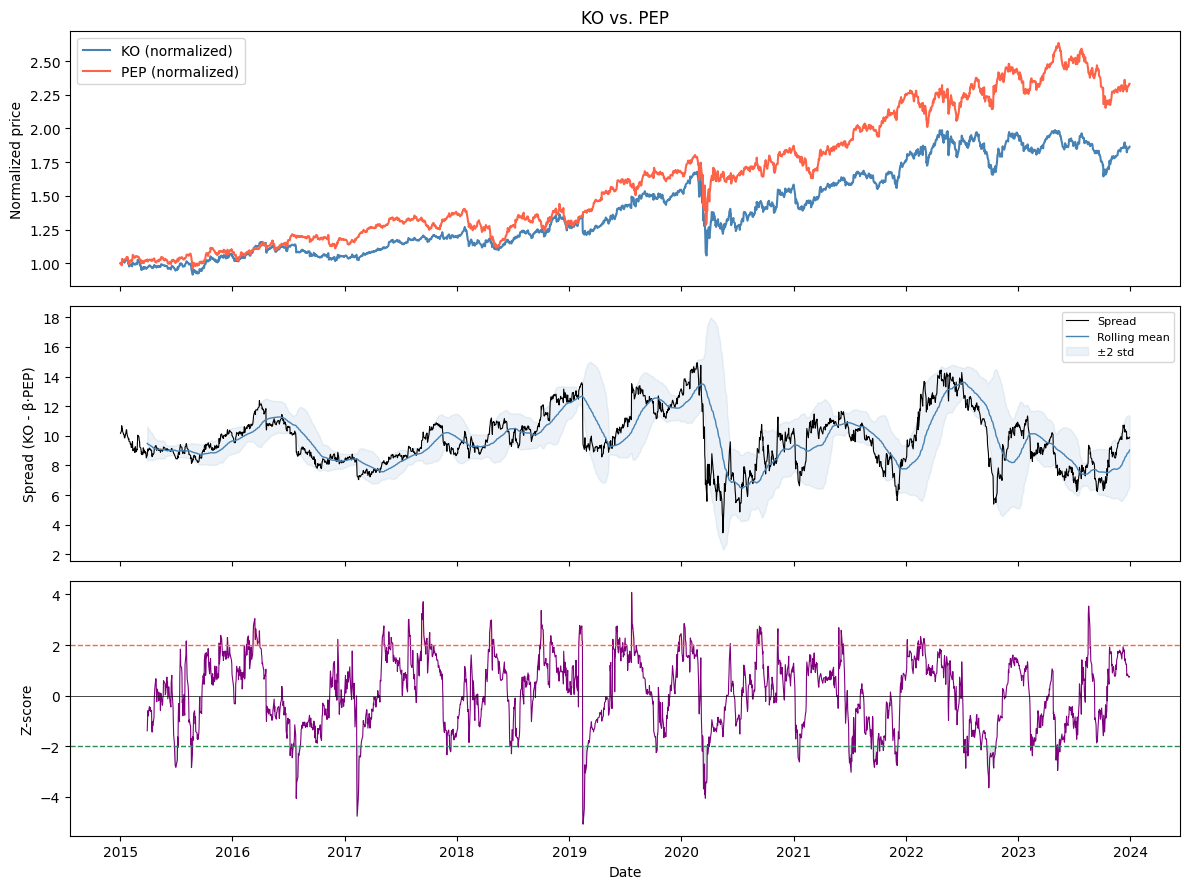

In [3]:
spread, beta = compute_spread(KO, PEP)
print(f"Hedge ratio β : {beta:.4f}")
print(f"  For every 1 share of KO, short {beta:.3f} shares of PEP")

window = 60
rolling_mean = spread.rolling(window).mean()
rolling_std  = spread.rolling(window).std()
z_score = (spread - rolling_mean) / rolling_std

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# normalized price series
axes[0].plot(KO.index,  KO  / KO.iloc[0],  label='KO (normalized)',  color='steelblue')
axes[0].plot(PEP.index, PEP / PEP.iloc[0], label='PEP (normalized)', color='tomato')
axes[0].set_ylabel('Normalized price')
axes[0].set_title('KO vs. PEP')
axes[0].legend()

# spread
axes[1].plot(spread.index, spread,        color='black',     linewidth=0.8, label='Spread')
axes[1].plot(spread.index, rolling_mean,  color='steelblue', linewidth=1.0, label='Rolling mean')
axes[1].fill_between(spread.index,
    rolling_mean + 2 * rolling_std,
    rolling_mean - 2 * rolling_std,
    alpha=0.1, color='steelblue', label='±2 std')
axes[1].set_ylabel('Spread (KO - β·PEP)')
axes[1].legend(fontsize=8)

# z-score
axes[2].plot(z_score.index, z_score, color='purple', linewidth=0.8)
axes[2].axhline( 2, color='tomato',   linestyle='--', linewidth=1)
axes[2].axhline(-2, color='seagreen', linestyle='--', linewidth=1)
axes[2].axhline( 0, color='black',    linestyle='-',  linewidth=0.5)
axes[2].fill_between(z_score.index, z_score,  2, where=(z_score >  2), alpha=0.2, color='tomato')
axes[2].fill_between(z_score.index, z_score, -2, where=(z_score < -2), alpha=0.2, color='seagreen')
axes[2].set_ylabel('Z-score')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

## Step 3 — Backtest

We backtest the signal on KO (the primary leg). Note: a complete pairs trade also includes the PEP leg — this backtest captures the KO side only. A full implementation would track both legs and net their P&L.

In [4]:
sig, spread, z_score, beta = signals(KO, PEP, window=60, entry_z=2.0, exit_z=0.5)
result = run(KO, sig, initial_capital=10_000, transaction_cost=0.001)

print("Performance (KO leg, 2015–2024)")
print()
summary(result['equity'], result['strategy_ret'])

Performance (KO leg, 2015–2024)

  Annualized return     : 1.77%
  Sharpe ratio          : 0.24
  Max drawdown          : -22.51%
  Win rate              : 40.26%
  Total trades          : 385


{'Annualized return': '1.77%',
 'Sharpe ratio': '0.24',
 'Max drawdown': '-22.51%',
 'Win rate': '40.26%',
 'Total trades': 385}

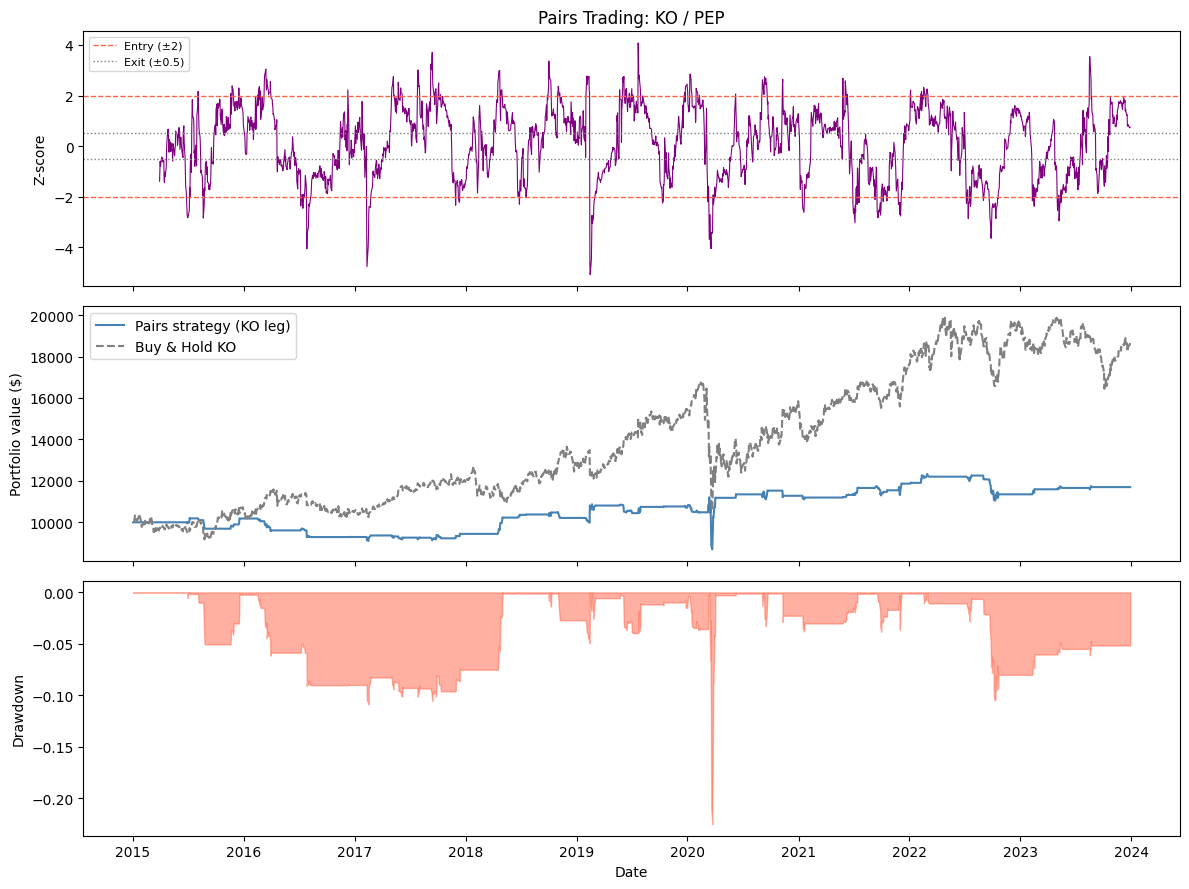

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# z-score with entry/exit zones
axes[0].plot(z_score.index, z_score, color='purple', linewidth=0.8)
axes[0].axhline( 2.0, color='tomato',   linestyle='--', linewidth=1, label='Entry (±2)')
axes[0].axhline(-2.0, color='tomato',   linestyle='--', linewidth=1)
axes[0].axhline( 0.5, color='gray',     linestyle=':',  linewidth=1, label='Exit (±0.5)')
axes[0].axhline(-0.5, color='gray',     linestyle=':',  linewidth=1)
axes[0].set_ylabel('Z-score')
axes[0].set_title('Pairs Trading: KO / PEP')
axes[0].legend(fontsize=8)

# equity
axes[1].plot(result.index, result['equity'],    label='Pairs strategy (KO leg)', color='steelblue')
axes[1].plot(result.index, result['bh_equity'], label='Buy & Hold KO',           color='gray', linestyle='--')
axes[1].set_ylabel('Portfolio value ($)')
axes[1].legend()

# drawdown
rolling_max = result['equity'].cummax()
drawdown    = (result['equity'] - rolling_max) / rolling_max
axes[2].fill_between(result.index, drawdown, 0, color='tomato', alpha=0.5)
axes[2].set_ylabel('Drawdown')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()

## Step 4 — Try other pairs

Cointegration is not guaranteed between any two stocks — it has to be tested. Below we scan a few candidate pairs and report whether they pass the test.

In [6]:
candidate_pairs = [
    ('KO',   'PEP'),   # beverages
    ('GS',   'MS'),    # investment banks
    ('XOM',  'CVX'),   # oil majors
    ('AAPL', 'MSFT'),  # big tech
    ('WMT',  'TGT'),   # retail
]

print(f"{'Pair':<15} {'p-value':>10} {'Cointegrated':>15}")
print("-" * 42)

for a, b in candidate_pairs:
    data = load_multi([a, b], start, end)
    s_a, s_b = data[a].dropna().align(data[b].dropna(), join='inner')
    is_coint, p = test_cointegration(s_a, s_b)
    print(f"{a+'/'+b:<15} {p:>10.4f} {str(is_coint):>15}")

Pair               p-value    Cointegrated
------------------------------------------
KO/PEP              0.0095            True
GS/MS               0.0184            True
XOM/CVX             0.6916           False
AAPL/MSFT           0.1609           False
WMT/TGT             0.9377           False
